In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('diabetes.csv')

FileNotFoundError: ignored

In [ ]:
df.head()

NameError: ignored

In [ ]:
print(f"Shape: {df.shape}\n")
print(f"\ndatatypes: \n{df.dtypes}")

Shape: (768, 9)


datatypes: 
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [ ]:
total_missing = df.isnull().sum().sum()
print("Total missing values in the DataFrame:", total_missing)

Total missing values in the DataFrame: 0


Conclusions drawn :

1.The dataset does not contain any null values .

2.The dataset has only 9 columns and all of them seem relevant

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


0    65.104167
1    34.895833
Name: Outcome, dtype: float64
Patients with Diabetes: 268
Patients without Diabetes: 500


<Axes: xlabel='Outcome', ylabel='count'>

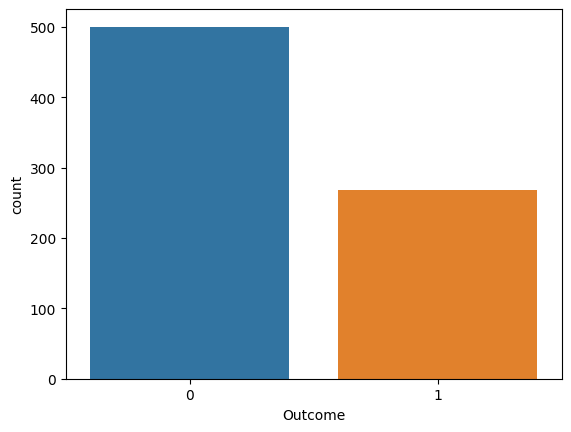

In [ ]:
df["Outcome"].value_counts()

#percentage distribution of the "Outcome"
print(100 * df["Outcome"].value_counts() / len(df))

with_diabetes = df['Outcome'].value_counts()[1]
without_diabetes = df['Outcome'].value_counts()[0]
print(f"Patients with Diabetes: {with_diabetes}\nPatients without Diabetes: {without_diabetes}")

sns.countplot(x="Outcome", data=df)

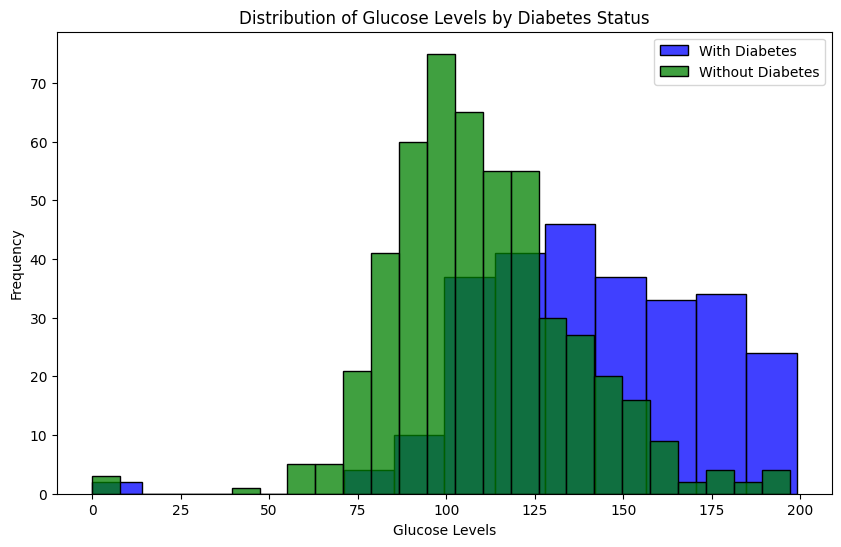

In [ ]:
with_diabetes = df[df['Outcome'] == 1]['Glucose']
without_diabetes = df[df['Outcome'] == 0]['Glucose']
plt.figure(figsize=(10, 6))
sns.histplot(with_diabetes, color='blue', label='With Diabetes')
sns.histplot(without_diabetes, color='green', label='Without Diabetes')
plt.xlabel('Glucose Levels')
plt.ylabel('Frequency')
plt.title('Distribution of Glucose Levels by Diabetes Status')
plt.legend()
plt.show()

In [ ]:
mean_age = df['Age'].mean()
median_age = df['Age'].median()
std_age = df['Age'].std()

print(f"Mean Age: {mean_age}")
print(f"Median Age: {median_age}")
print(f"Standard Deviation of Age: {std_age}")

Mean Age: 33.240885416666664
Median Age: 29.0
Standard Deviation of Age: 11.760231540678685


In [ ]:
age_groups = df.groupby('Age')['Outcome'].mean()

<ipython-input-21-9b69e6f899ca>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Age', y='Outcome', data=df, ci=None)


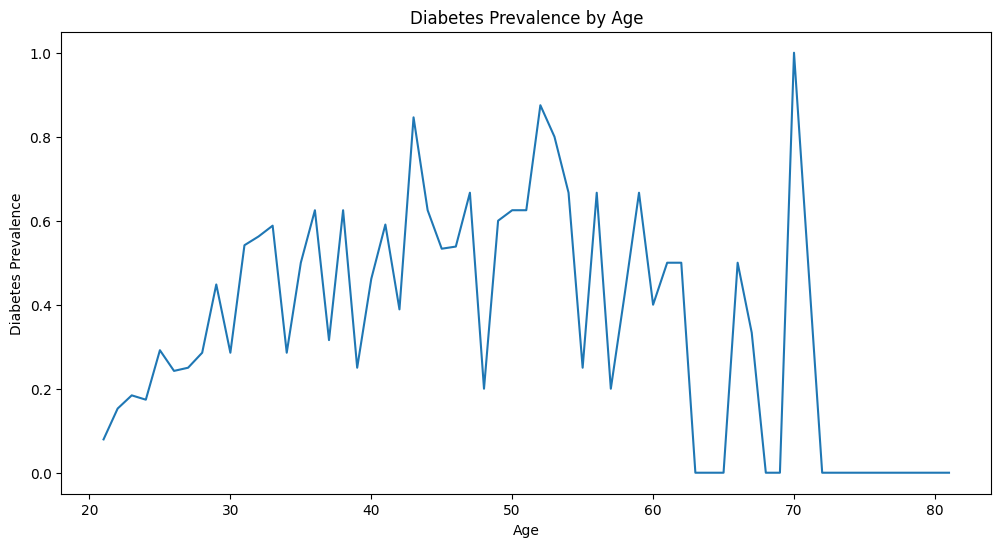

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Age', y='Outcome', data=df, ci=None)
plt.title('Diabetes Prevalence by Age')
plt.xlabel('Age')
plt.ylabel('Diabetes Prevalence')
plt.show()

In [ ]:
correlation_matrix = df[['BMI', 'Skin Thickness']].corr()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='BMI', y='Skin Thickness', data=df)
plt.title('Scatter Plot: BMI vs. Skin Thickness')
plt.xlabel('BMI')
plt.ylabel('Skin Thickness')
plt.show()

NameError: ignored

In [ ]:
df.corr()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


Therefore, for each variable, the correlation is as follows:

Pregnancies (+0.22): Positive correlation. Higher number of pregnancies slightly increases diabetes likelihood.

Glucose (+0.47): Positive correlation. Higher glucose levels significantly indicate higher diabetes risk.

BloodPressure (+0.07): Positive correlation. Slight increase in blood pressure, slight increase in diabetes risk.

SkinThickness (+0.07): Positive correlation. Slight increase in skin thickness, slight increase in diabetes risk.

Insulin (+0.13): Positive correlation. Slight increase in insulin levels, slight increase in diabetes risk.

BMI (+0.29): Positive correlation. Higher BMI indicates higher diabetes likelihood.

DiabetesPedigreeFunction (+0.17): Positive correlation. Slight increase in diabetes pedigree function, slight increase in diabetes risk.

Age (+0.24): Positive correlation. Older age is associated with higher diabetes risk.

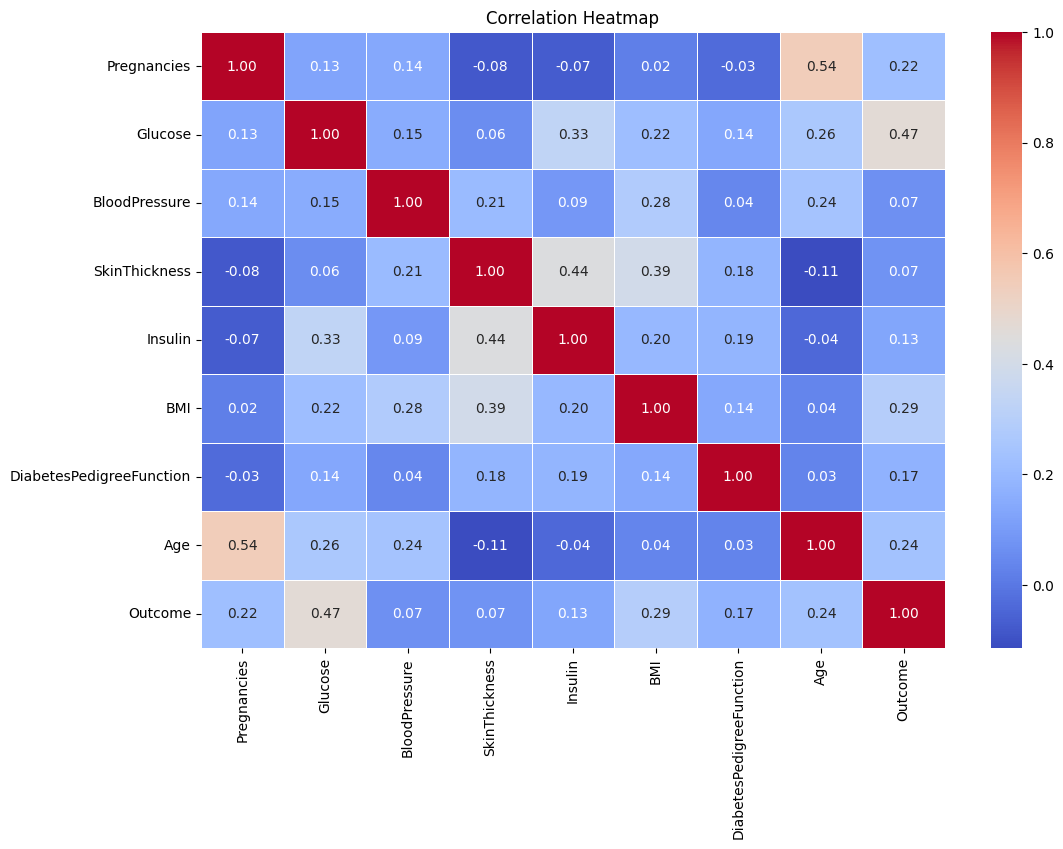

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()